# 06 Bivariate Analysis

## Objective

Objective:
Perform bivariate analysis to understand how individual features
relate to the target variable `Churn`.

This step helps in:
- Comparing feature behavior across churn classes
- Identifying potentially important predictors
- Detecting class-specific patterns in numerical and categorical features
- Preparing for feature selection and modeling


## Imports


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

def plot_mosaic(ax, df_input, feature, target):
    table = df_input.groupby([feature, target]).size().unstack(fill_value=0)
    table = table.reindex(df_input[feature].value_counts().index)
    total = table.sum().sum()
    colors = sns.color_palette("Set2", n_colors=max(table.shape[1], 2))
    x_start = 0.0
    tick_positions = []

    for category in table.index:
        category_total = table.loc[category].sum()
        width = category_total / total if total else 0
        y_start = 0.0

        for color_index, target_value in enumerate(table.columns):
            value = table.loc[category, target_value]
            height = value / category_total if category_total else 0
            rect = Rectangle(
                (x_start, y_start),
                width,
                height,
                facecolor=colors[color_index],
                edgecolor="white",
                linewidth=1,
            )
            ax.add_patch(rect)
            y_start += height

        tick_positions.append(x_start + width / 2)
        x_start += width

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([str(value) for value in table.index], rotation=45, ha="right")
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.legend(
        handles=[
            Rectangle((0, 0), 1, 1, facecolor=colors[idx], edgecolor="white")
            for idx in range(len(table.columns))
        ],
        labels=[str(value) for value in table.columns],
        title=target,
        loc="best",
    )

sns.set_theme(style="whitegrid")


## Report Paths

Store bivariate analysis outputs in dedicated report folders so tables and figures stay easy to find.


In [4]:
REPORTS_DIR = project_root / "reports"
BIVARIATE_FIGURES_DIR = REPORTS_DIR / "figures" / "bivariate"
BIVARIATE_TABLES_DIR = REPORTS_DIR / "tables" / "bivariate"
NUMERICAL_VS_TARGET_FIGURES_DIR = BIVARIATE_FIGURES_DIR / "numerical_vs_target"
NUMERICAL_VS_TARGET_TABLES_DIR = BIVARIATE_TABLES_DIR / "numerical_vs_target"
CATEGORICAL_VS_TARGET_FIGURES_DIR = BIVARIATE_FIGURES_DIR / "categorical_vs_target"
CATEGORICAL_VS_TARGET_TABLES_DIR = BIVARIATE_TABLES_DIR / "categorical_vs_target"

for path in [
    NUMERICAL_VS_TARGET_FIGURES_DIR,
    NUMERICAL_VS_TARGET_TABLES_DIR,
    CATEGORICAL_VS_TARGET_FIGURES_DIR,
    CATEGORICAL_VS_TARGET_TABLES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

{
    "numerical_vs_target_figures": NUMERICAL_VS_TARGET_FIGURES_DIR,
    "numerical_vs_target_tables": NUMERICAL_VS_TARGET_TABLES_DIR,
    "categorical_vs_target_figures": CATEGORICAL_VS_TARGET_FIGURES_DIR,
    "categorical_vs_target_tables": CATEGORICAL_VS_TARGET_TABLES_DIR,
}


{'numerical_vs_target_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/bivariate/numerical_vs_target'),
 'numerical_vs_target_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/bivariate/numerical_vs_target'),
 'categorical_vs_target_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/bivariate/categorical_vs_target'),
 'categorical_vs_target_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/bivariate/categorical_vs_target')}

## Load Data and Separate Feature Types

Separate numerical and categorical features because the choice of comparison chart depends on feature type.


In [5]:
df = load_cleaned_data()

target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]

feature_groups = {
    "target_column": target_column,
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
}

feature_groups


{'target_column': 'Churn',
 'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod']}

## Numerical Features vs Target

Compare each numerical feature across churn classes to see whether churned and non-churned customers differ in their distributions.


In [6]:
numerical_vs_target_summary = (
    df.groupby(target_column)[numerical_columns]
    .agg(["mean", "median", "std"])
    .round(2)
)

numerical_vs_target_summary.to_csv(
    NUMERICAL_VS_TARGET_TABLES_DIR / "numerical_vs_target_summary.csv"
)

display(numerical_vs_target_summary)


tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

This summary table compares the numerical features across the two churn classes. It helps show whether churned customers tend to have lower or higher values than non-churned customers, and whether the spread within each class is narrow or wide. If the class-wise means or medians differ clearly, that feature may become important later in churn prediction.


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_47264/194556595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_column, y=column, ax=box_ax, palette="Set2")
/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_47264/194556595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_column, y=column, ax=box_ax, palette="Set2")
/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_47264/194556595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_column, y=column, ax=b

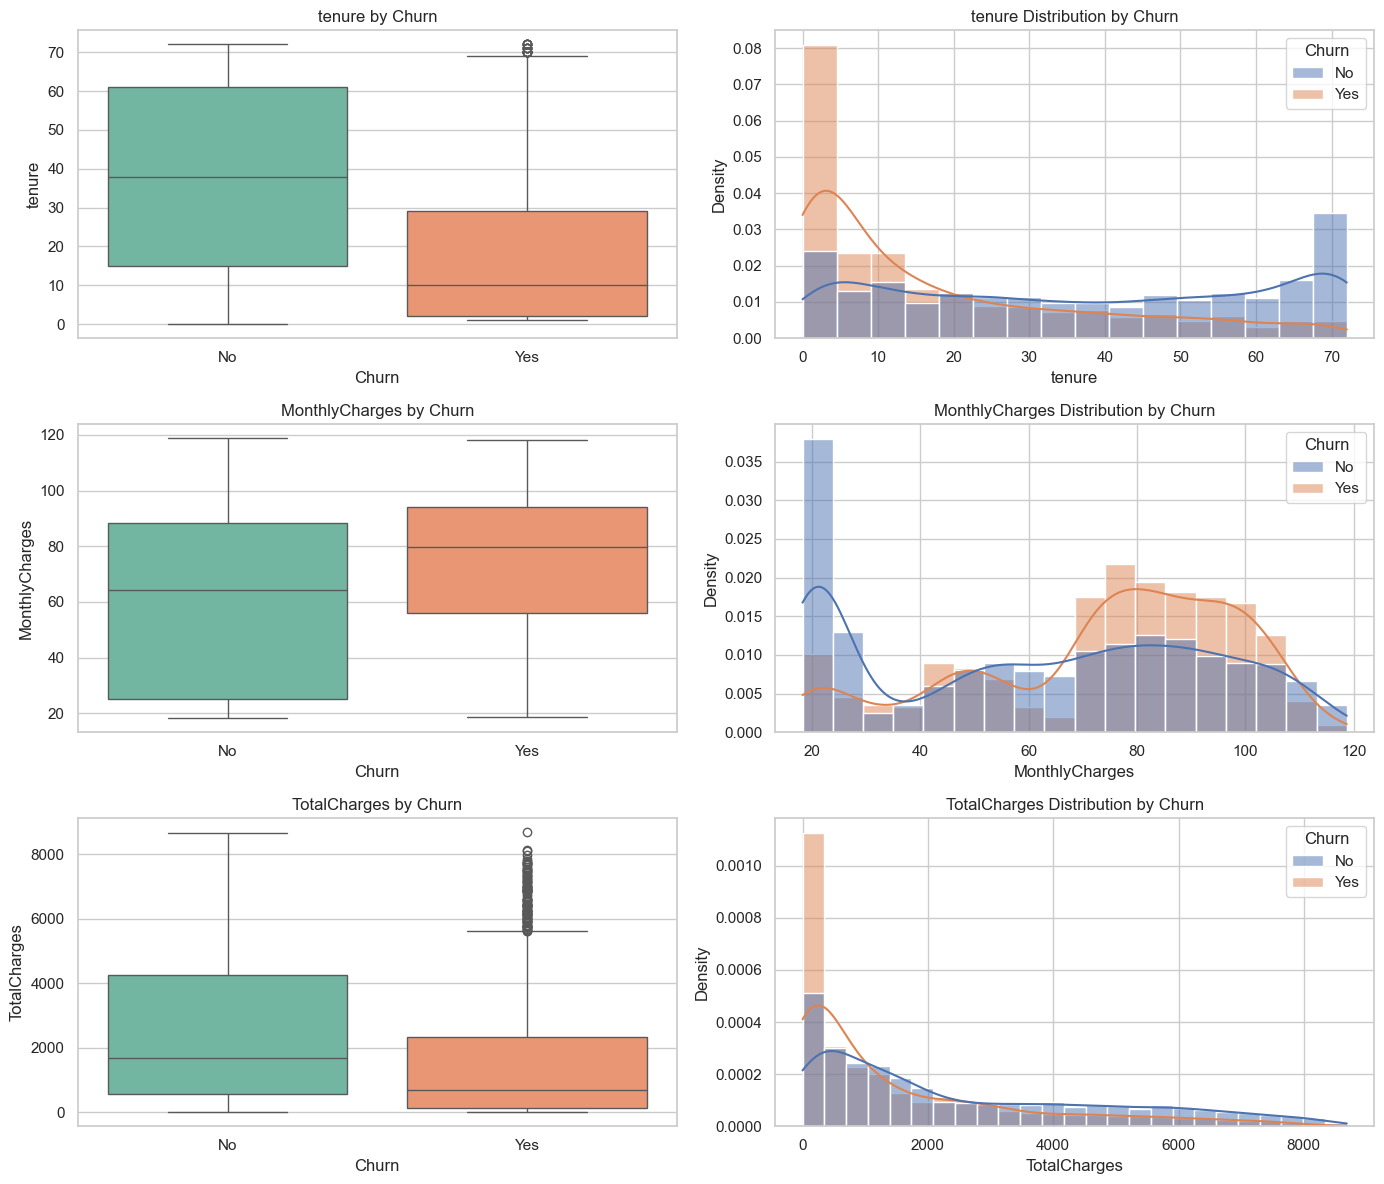

In [18]:
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(14, 4 * len(numerical_columns)))

if len(numerical_columns) == 1:
    axes = [axes]

for index, column in enumerate(numerical_columns):
    box_ax, hist_ax = axes[index]

    sns.boxplot(data=df, x=target_column, y=column, ax=box_ax, palette="Set2")
    box_ax.set_title(f"{column} by {target_column}")
    box_ax.set_xlabel(target_column)
    box_ax.set_ylabel(column)

    sns.histplot(data=df, x=column, hue=target_column, kde=True, stat="density", common_norm=False, ax=hist_ax)
    hist_ax.set_title(f"{column} Distribution by {target_column}")
    hist_ax.set_xlabel(column)
    hist_ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig(
    NUMERICAL_VS_TARGET_FIGURES_DIR / "numerical_vs_target_distributions.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


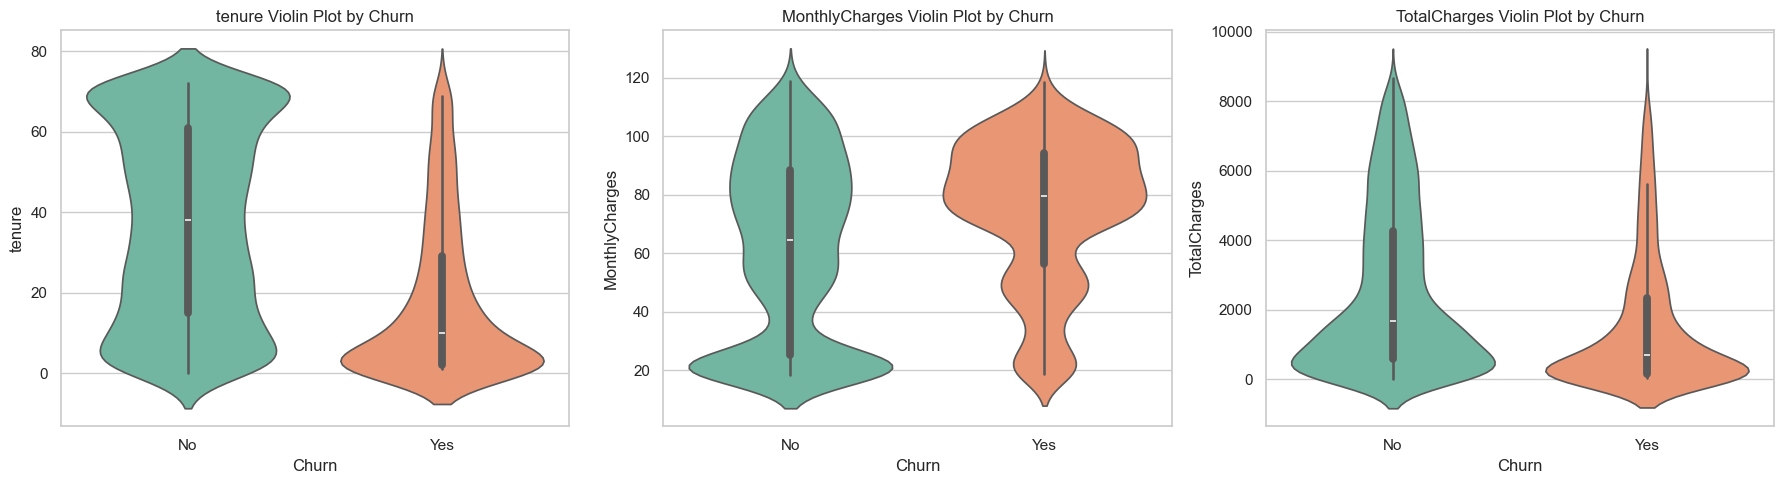

In [19]:
fig, axes = plt.subplots(1, len(numerical_columns), figsize=(6 * len(numerical_columns), 5))

if len(numerical_columns) == 1:
    axes = [axes]

for index, column in enumerate(numerical_columns):
    ax = axes[index]
    sns.violinplot(data=df, x=target_column, y=column, ax=ax, hue=target_column, palette="Set2", legend=False)
    ax.set_title(f"{column} Violin Plot by {target_column}")
    ax.set_xlabel(target_column)
    ax.set_ylabel(column)

plt.tight_layout()
plt.savefig(
    NUMERICAL_VS_TARGET_FIGURES_DIR / "numerical_vs_target_violinplots.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


### Numerical vs Target Insights

- `tenure` shows the clearest separation between churn classes: customers with `Churn = Yes` are concentrated at much lower tenure values, while customers with `Churn = No` are more common at medium and high tenure.
- `MonthlyCharges` tends to be higher for churned customers, and its distribution is shifted upward for `Churn = Yes`, which suggests that customers paying more per month are more likely to leave.
- `TotalCharges` is lower for churned customers and much higher for non-churned customers, which is consistent with the idea that retained customers stay longer and accumulate larger lifetime charges.
- The distribution plots and violin plots add shape-based evidence to the boxplots: `tenure` provides the strongest visible class separation, while `MonthlyCharges` and `TotalCharges` also show meaningful but overlapping differences between churn groups.
- The violin plots highlight where customer values are most concentrated: churned customers cluster at low `tenure`, relatively high `MonthlyCharges`, and low `TotalCharges`, while non-churned customers are denser at higher `tenure` and higher `TotalCharges` ranges.
- Together, these plots suggest a common churn profile of lower tenure, relatively higher monthly charges, and lower total charges.


## Plot Guide for Numerical Features

- **Box plot**: use it when you want a compact summary of median, quartiles, spread, and possible outliers across churn classes.
- **Violin plot**: use it when you want to see the shape and density concentration of each class, especially where values are most clustered.
- **Histogram with hue**: use it when you want to inspect the actual binned distribution and how much the churn classes overlap.
- **KDE curve**: use it when you want a smoother class-wise comparison of distribution shape without relying only on histogram bars.
- Together, these plots work best as a set: box plots summarize, violin plots show density, histograms show overlap, and KDE highlights the smoothed distribution trend.


## Categorical Features vs Target

Compare each categorical feature against `Churn` to see which categories are associated with higher or lower churn counts and churn rates.


In [7]:
categorical_vs_target_rows = []

for column in categorical_columns:
    category_target_table = (
        df.groupby([column, target_column]).size().unstack(fill_value=0)
    )
    category_target_table["total_count"] = category_target_table.sum(axis=1)
    category_target_table["churn_rate_pct"] = (
        category_target_table.get("Yes", pd.Series(0, index=category_target_table.index))
        .div(category_target_table["total_count"])
        .mul(100)
        .round(2)
    )
    category_target_table = category_target_table.sort_values("churn_rate_pct", ascending=False)

    top_category = category_target_table["churn_rate_pct"].idxmax()
    categorical_vs_target_rows.append(
        {
            "feature": column,
            "category_count": int(category_target_table.shape[0]),
            "highest_churn_category": top_category,
            "highest_churn_rate_pct": float(category_target_table.loc[top_category, "churn_rate_pct"]),
            "largest_category_count": int(category_target_table["total_count"].max()),
        }
    )

    safe_name = column.lower().replace(" ", "_")
    category_target_table.to_csv(
        CATEGORICAL_VS_TARGET_TABLES_DIR / f"{safe_name}_vs_target.csv"
    )

    print(f"\n{column} vs {target_column}")
    display(category_target_table)

categorical_vs_target_summary_df = pd.DataFrame(categorical_vs_target_rows)
categorical_vs_target_summary_df.to_csv(
    CATEGORICAL_VS_TARGET_TABLES_DIR / "categorical_vs_target_summary.csv",
    index=False,
)

display(categorical_vs_target_summary_df)



gender vs Churn


Churn,No,Yes,total_count,churn_rate_pct
gender,,,,
Female,2549,939,3488,26.92
Male,2625,930,3555,26.16



SeniorCitizen vs Churn


Churn,No,Yes,total_count,churn_rate_pct
SeniorCitizen,,,,
1,666,476,1142,41.68
0,4508,1393,5901,23.61



Partner vs Churn


...


PaperlessBilling vs Churn


Churn,No,Yes,total_count,churn_rate_pct
PaperlessBilling,,,,
Yes,2771,1400,4171,33.57
No,2403,469,2872,16.33



PaymentMethod vs Churn


Churn,No,Yes,total_count,churn_rate_pct
PaymentMethod,,,,
Electronic check,1294,1071,2365,45.29
Mailed check,1304,308,1612,19.11
Bank transfer (automatic),1286,258,1544,16.71
Credit card (automatic),1290,232,1522,15.24


,feature,category_count,highest_churn_category,highest_churn_rate_pct,largest_category_count
0,gender,2,Female,26.92,3555
1,SeniorCitizen,2,1,41.68,5901
2,Partner,2,No,32.96,3641
3,Dependents,2,No,31.28,4933
4,PhoneService,2,Yes,26.71,6361
5,MultipleLines,3,Yes,28.61,3390
6,InternetService,3,Fiber optic,41.89,3096
7,OnlineSecurity,3,No,41.77,3498
8,OnlineBackup,3,No,39.93,3088
9,DeviceProtection,3,No,39.13,3095


This section shows how churn is distributed inside each categorical feature. The per-feature tables help identify dominant categories, higher-churn categories, and categories that may become important later in churn modeling.


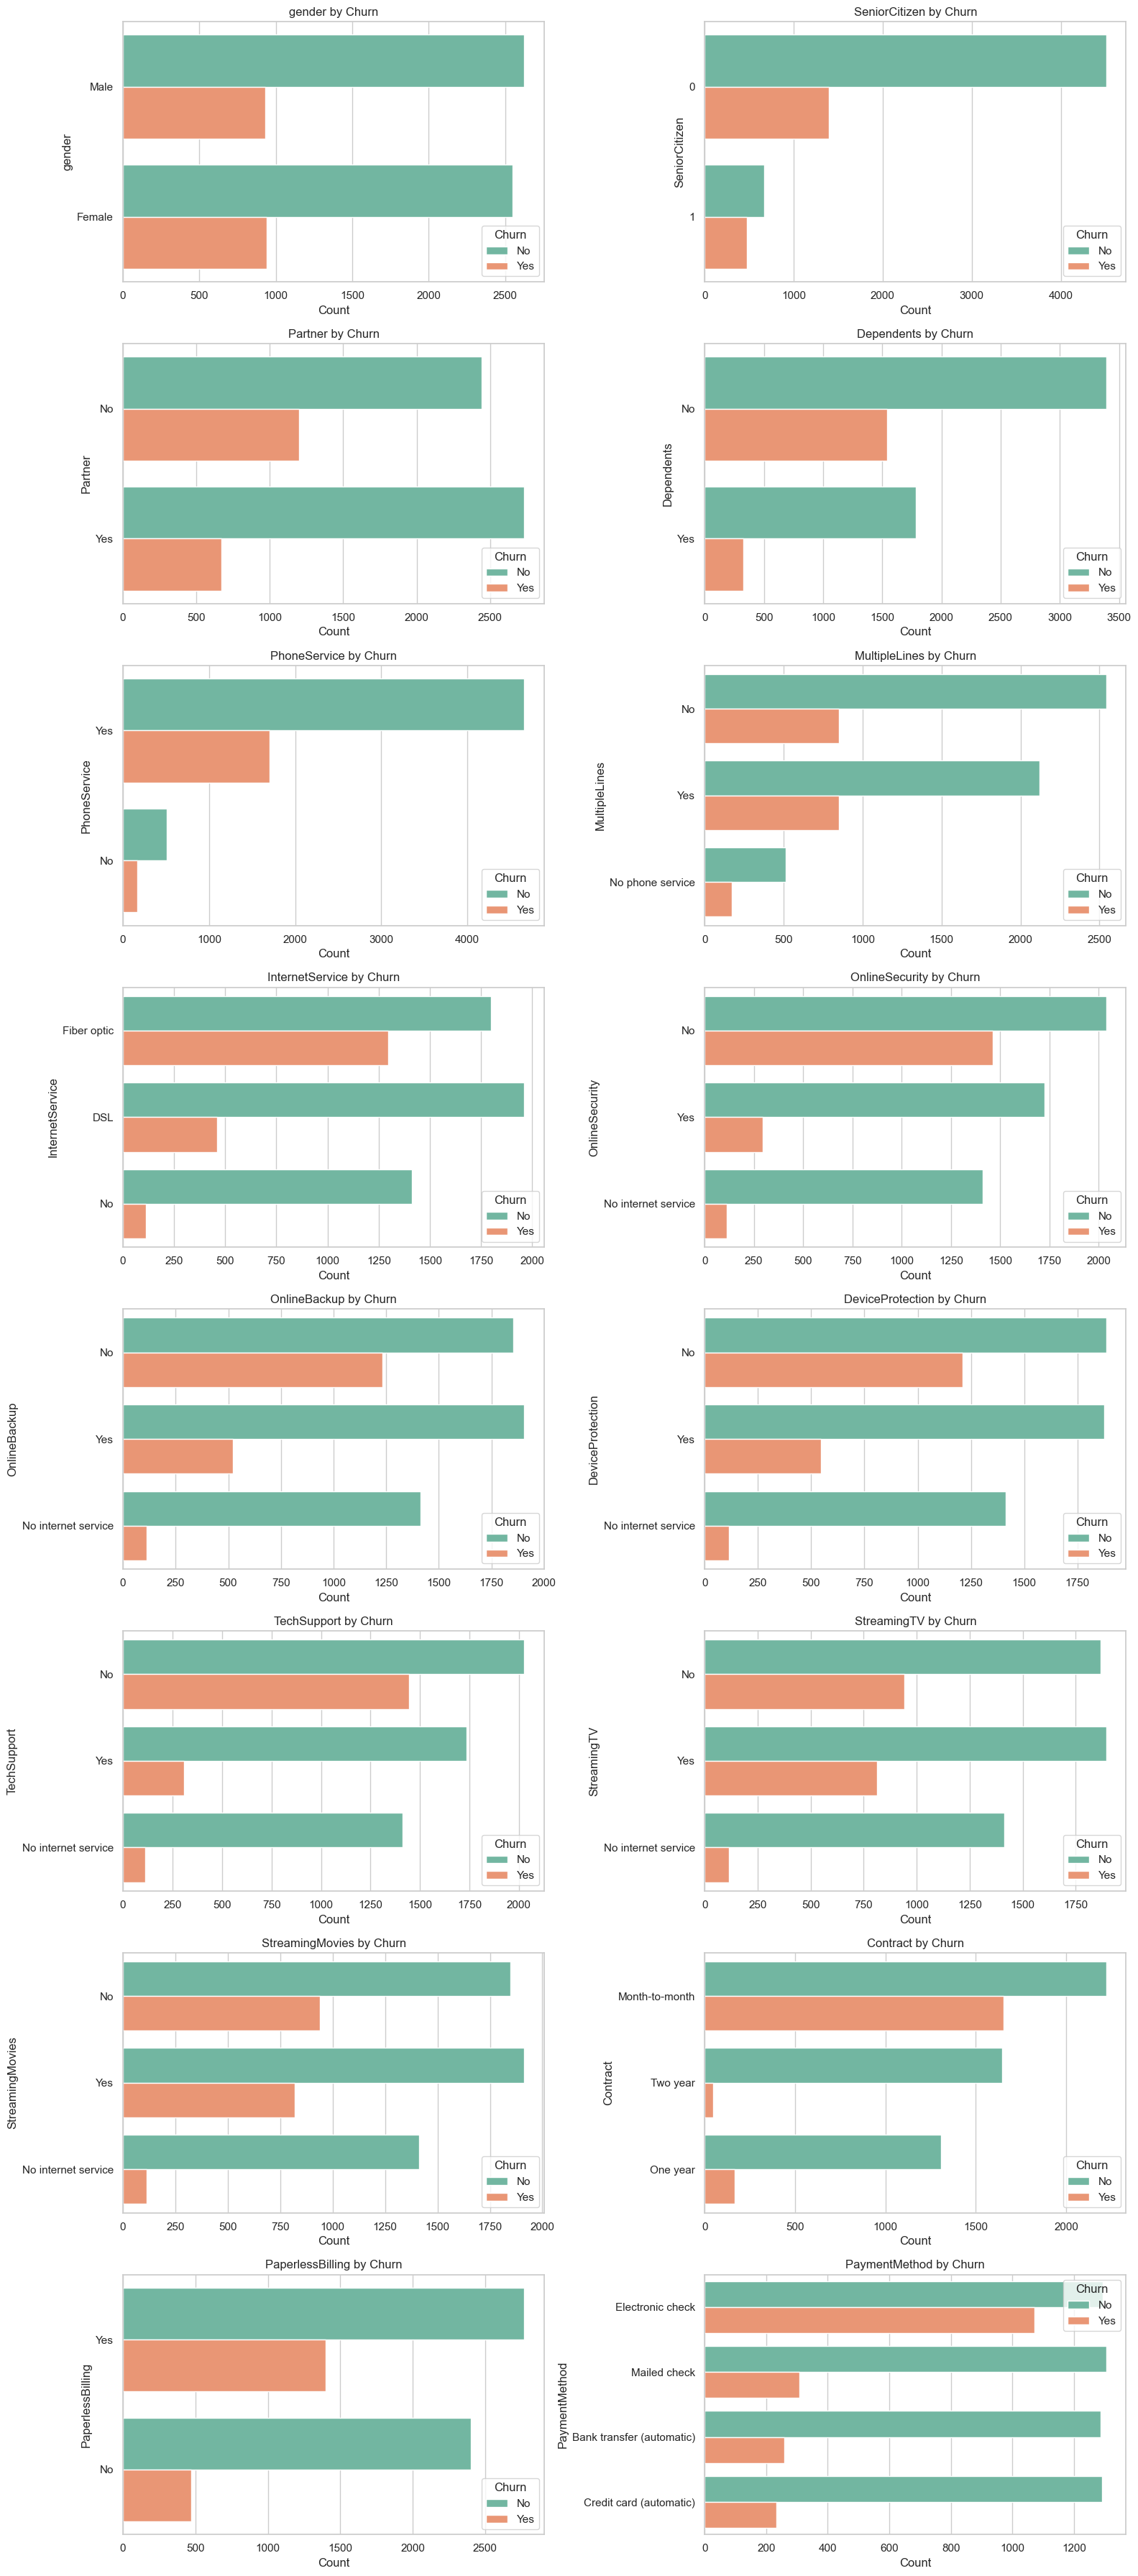

In [21]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    ax = axes[index]
    order = df[column].value_counts().index
    sns.countplot(
        data=df,
        y=column,
        hue=target_column,
        order=order,
        ax=ax,
        palette="Set2",
    )
    ax.set_title(f"{column} by {target_column}")
    ax.set_xlabel("Count")
    ax.set_ylabel(column)

for index in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.savefig(
    CATEGORICAL_VS_TARGET_FIGURES_DIR / "categorical_vs_target_countplots.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


This figure is a grouped horizontal count plot. It shows raw customer counts for each category split by `Churn = Yes` and `Churn = No`. In simple terms, the grouped count plot shows numbers, so it is useful for seeing how many customers belong to each group.


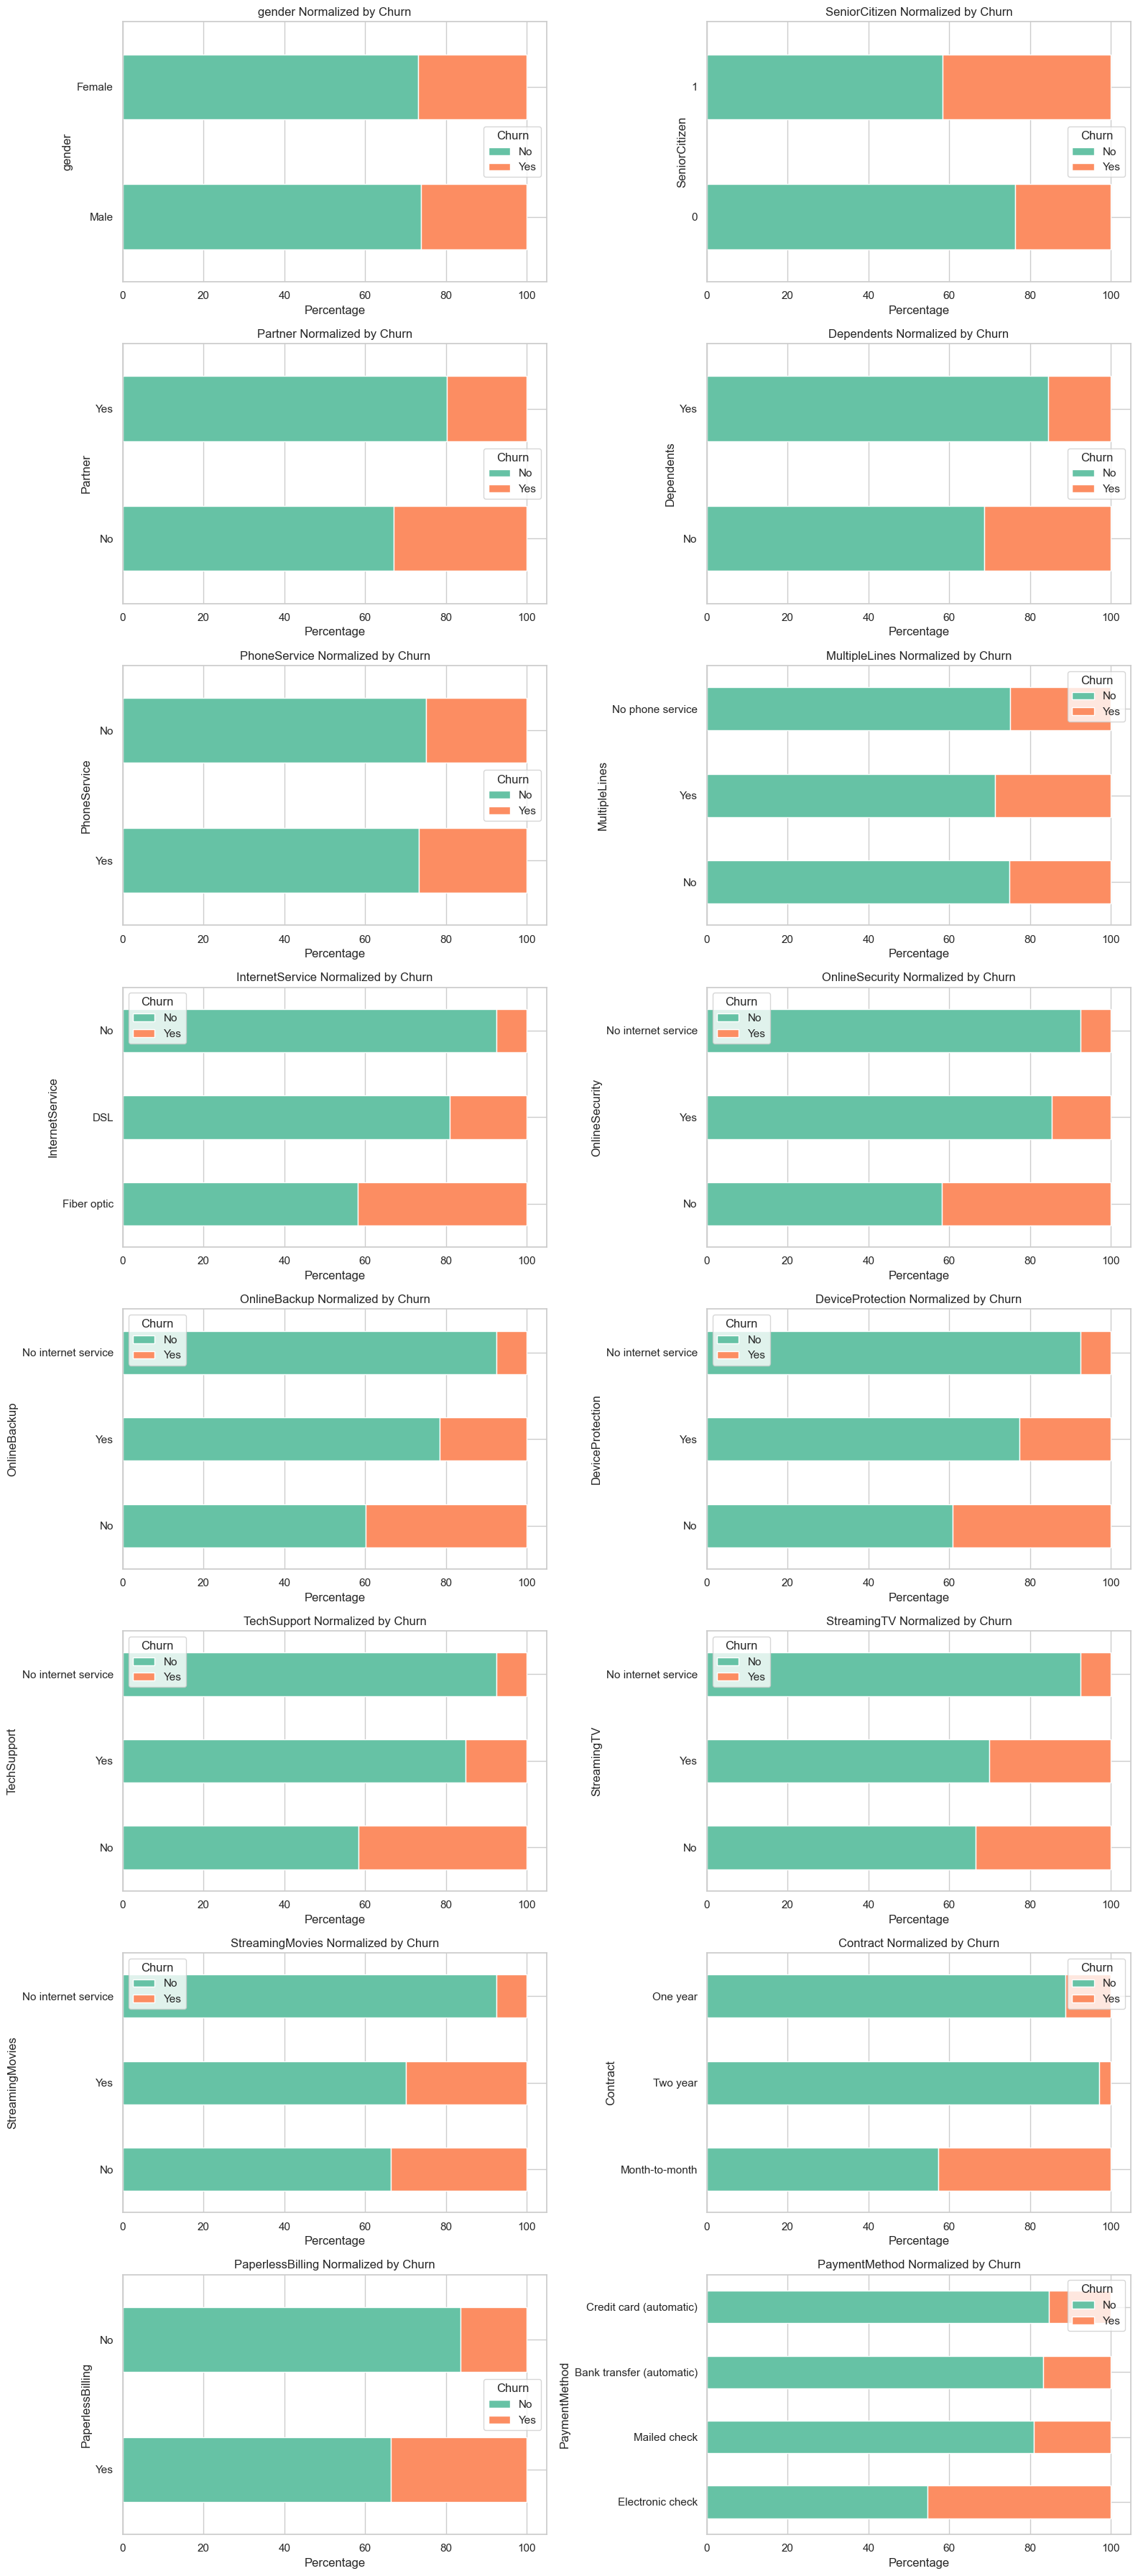

In [8]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    ax = axes[index]
    normalized_table = (
        df.groupby([column, target_column]).size().unstack(fill_value=0)
    )
    normalized_table = normalized_table.div(normalized_table.sum(axis=1), axis=0).mul(100)
    normalized_table = normalized_table.reindex(df[column].value_counts().index)
    normalized_table.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=sns.color_palette("Set2", n_colors=max(normalized_table.shape[1], 2)),
    )
    ax.set_title(f"{column} Normalized by {target_column}")
    ax.set_xlabel("Percentage")
    ax.set_ylabel(column)
    ax.legend(title=target_column)

for index in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.savefig(
    CATEGORICAL_VS_TARGET_FIGURES_DIR / "categorical_vs_target_normalized_stacked.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


This figure is a 100% stacked horizontal bar chart. It shows the percentage split of `Churn = Yes` and `Churn = No` within each category, and every bar totals 100%. In simple terms, the 100% stacked bar chart shows percentages, so it is better for comparing churn tendency across categories with different total sizes.


Grouped bar plots of the aggregated target show the churn rate directly for each category. This is useful when you want a simpler chart that compares category risk without mixing raw counts and percentages in the same view.


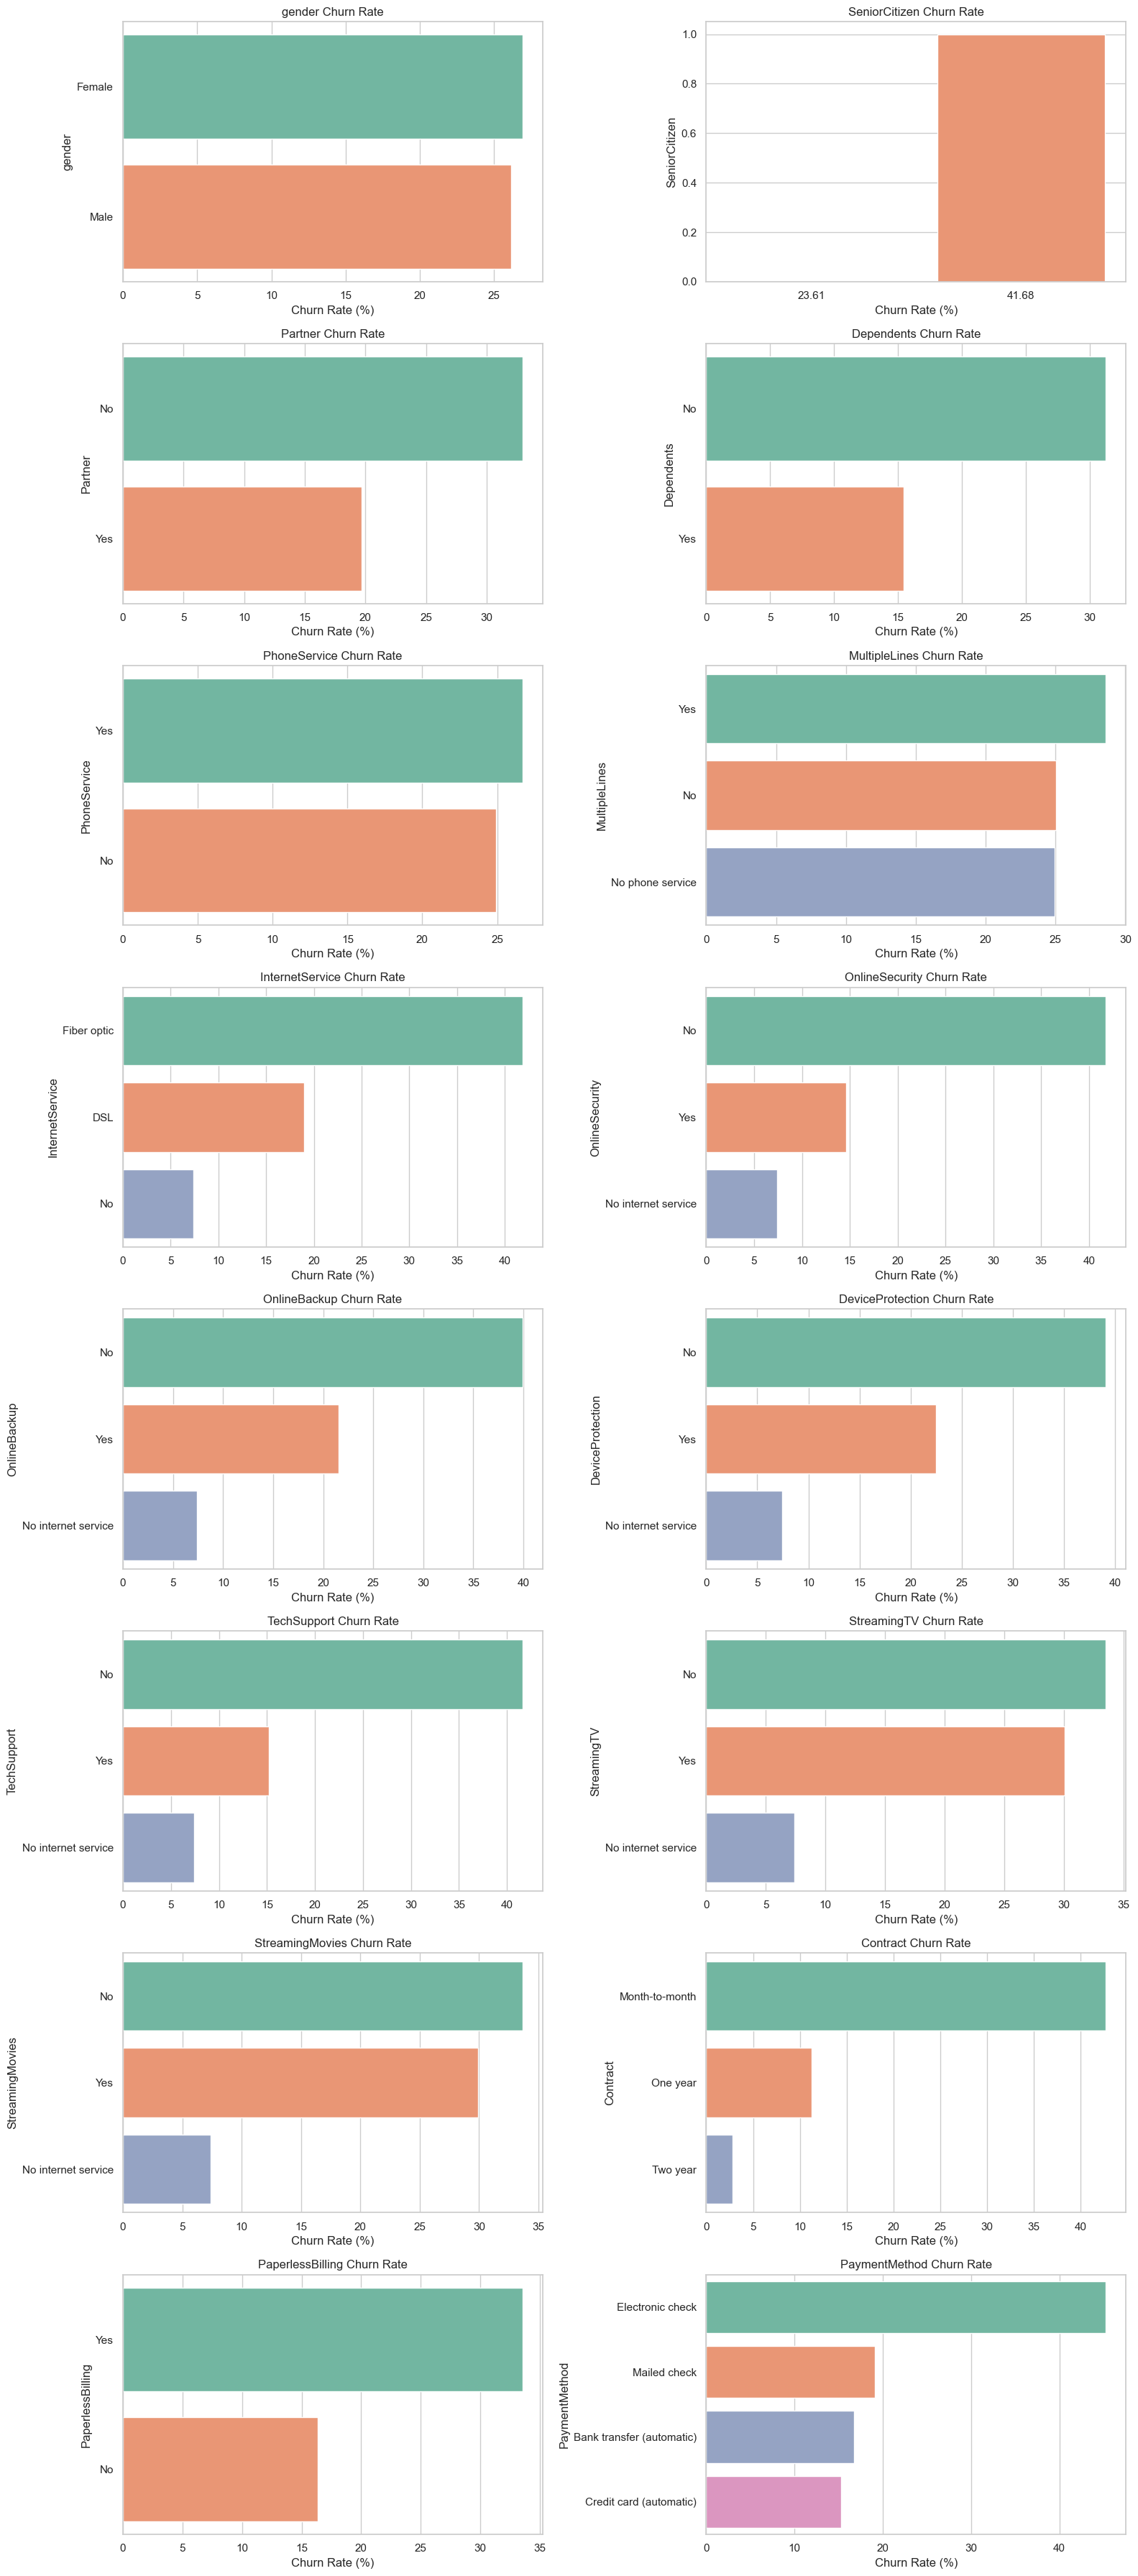

In [26]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    ax = axes[index]
    churn_rate_table = (
        df.groupby(column)[target_column]
        .apply(lambda values: values.eq("Yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
    )
    sns.barplot(
        x=churn_rate_table.values,
        y=churn_rate_table.index,
        ax=ax,
        hue=churn_rate_table.index,
        palette="Set2",
        legend=False,
    )
    ax.set_title(f"{column} Churn Rate")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel(column)

for index in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.savefig(
    CATEGORICAL_VS_TARGET_FIGURES_DIR / "categorical_vs_target_churn_rate_bars.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


This horizontal bar chart shows the churn rate (%) for each category of a categorical feature. It helps compare which groups have a higher or lower likelihood of churn more directly than raw count plots, where a longer bar means a higher churn rate.


The mosaic plot shows both category size and churn composition in a single chart. Wider blocks represent categories with more customers, while the vertical split within each block shows the proportion of churned and non-churned customers. This helps identify categories that are both large and associated with higher churn.


In [11]:
def plot_mosaic(ax, df_input, feature, target):
    table = df_input.groupby([feature, target]).size().unstack(fill_value=0)
    table = table.reindex(df_input[feature].value_counts().index)
    total = table.sum().sum()
    colors = sns.color_palette("Set2", n_colors=max(table.shape[1], 2))
    x_start = 0.0
    tick_positions = []

    for category in table.index:
        category_total = table.loc[category].sum()
        width = category_total / total if total else 0
        y_start = 0.0

        for color_index, target_value in enumerate(table.columns):
            value = table.loc[category, target_value]
            height = value / category_total if category_total else 0
            rect = Rectangle(
                (x_start, y_start),
                width,
                height,
                facecolor=colors[color_index],
                edgecolor="white",
                linewidth=1,
            )
            ax.add_patch(rect)
            y_start += height

        tick_positions.append(x_start + width / 2)
        x_start += width

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([str(value) for value in table.index], rotation=45, ha="right")
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.legend(
        handles=[
            Rectangle((0, 0), 1, 1, facecolor=colors[idx], edgecolor="white")
            for idx in range(len(table.columns))
        ],
        labels=[str(value) for value in table.columns],
        title=target,
        loc="best",
    )


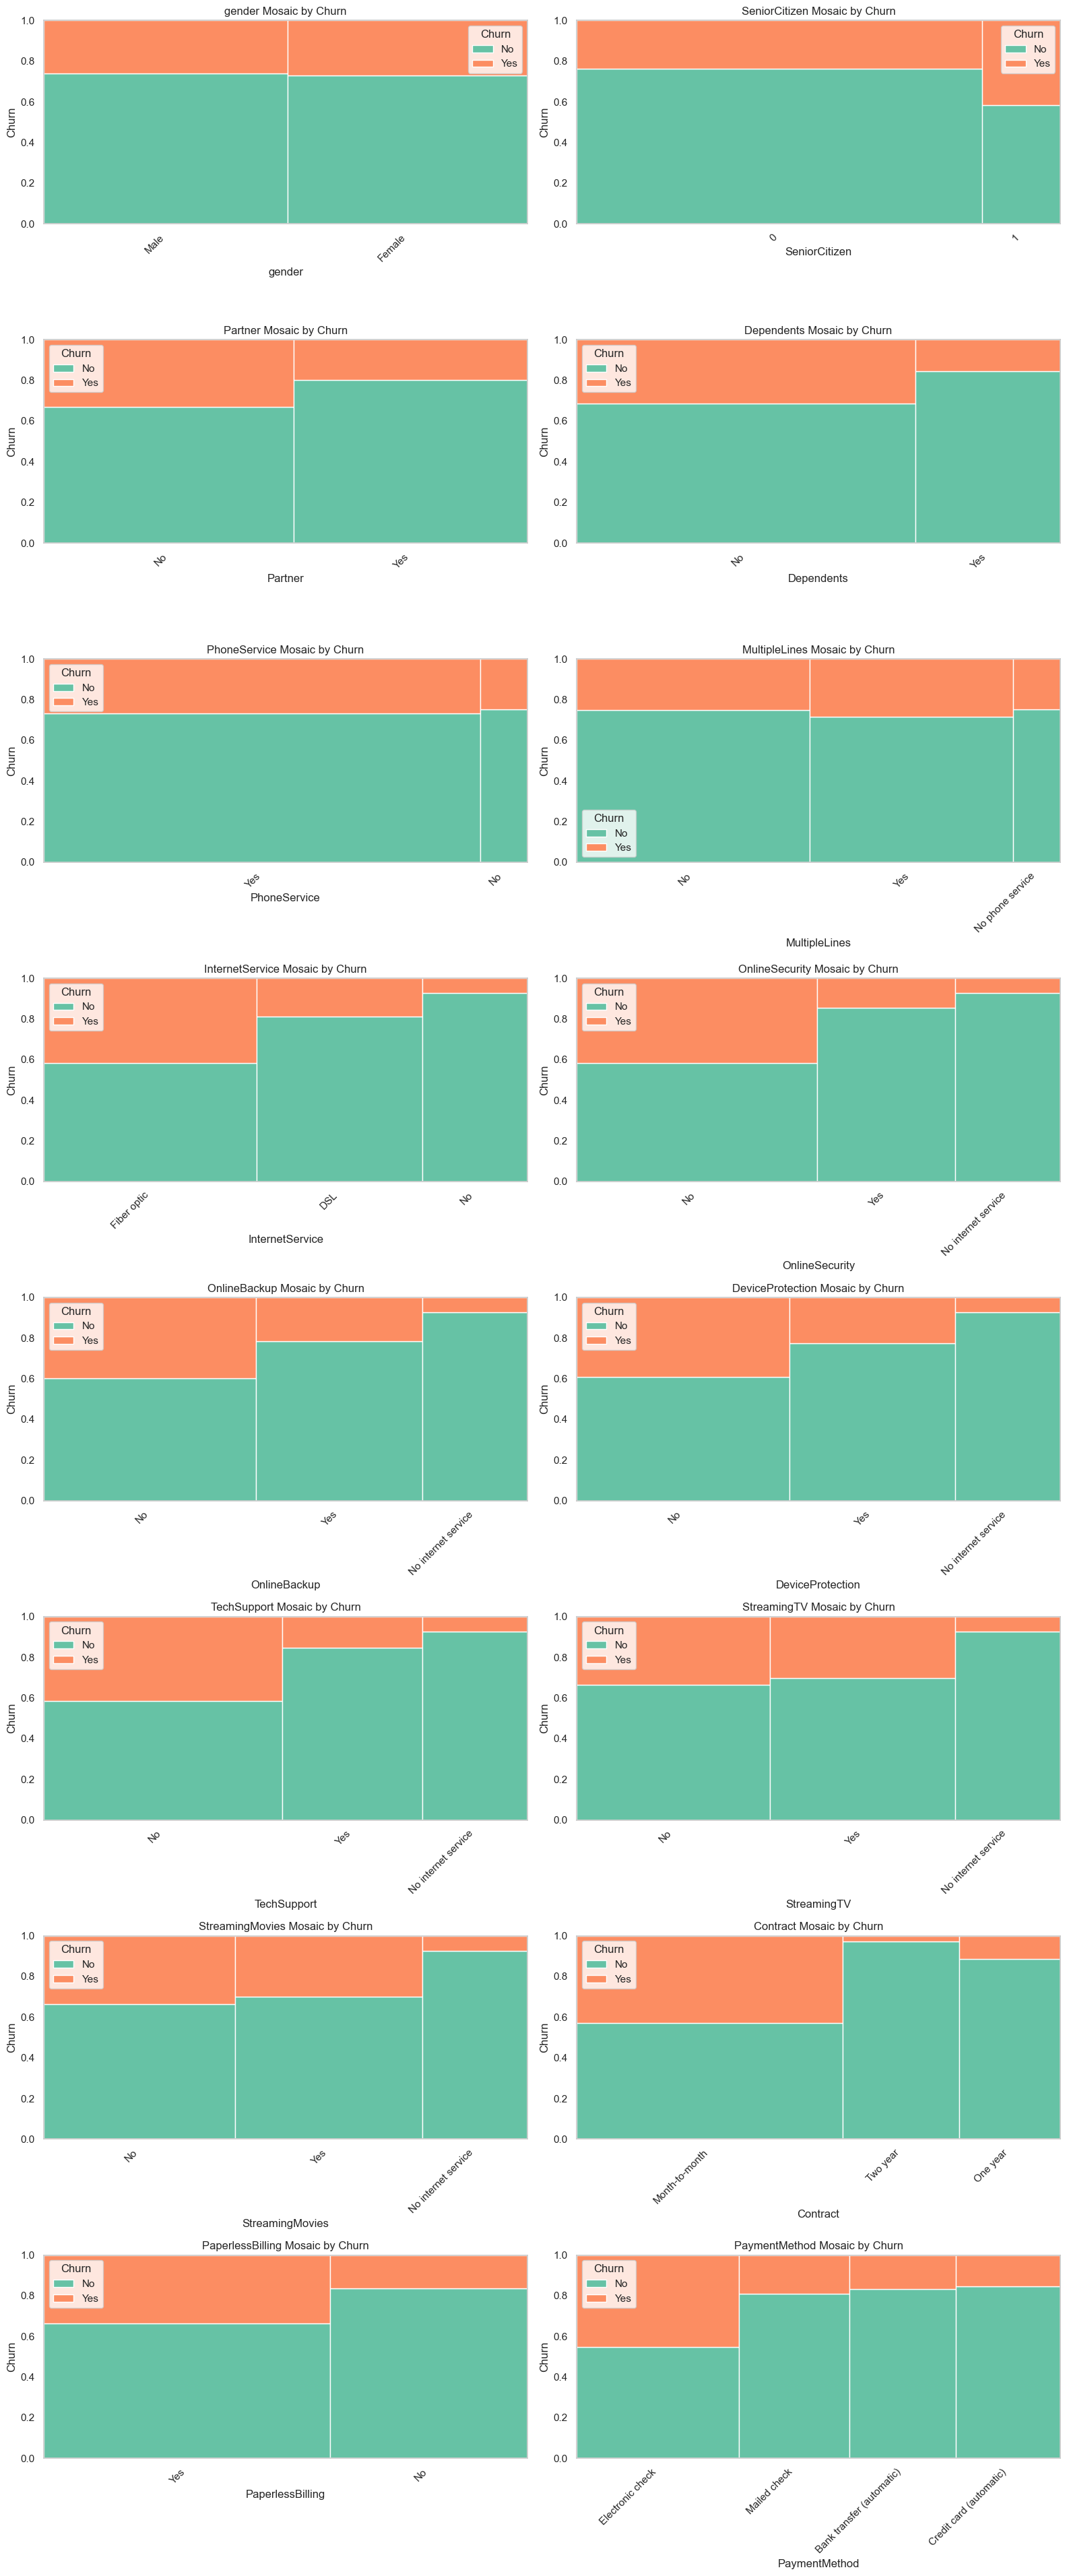

In [ ]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.8 * n_rows))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    ax = axes[index]
    plot_mosaic(ax, df, column, target_column)
    ax.set_title(f"{column} Mosaic by {target_column}")

for index in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.savefig(
    CATEGORICAL_VS_TARGET_FIGURES_DIR / "categorical_vs_target_mosaic.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


Heatmaps are useful cross-tab visualizations because they show the churn percentage for each category-target combination using color intensity. Darker cells highlight categories where the proportion of `Churn = Yes` or `Churn = No` is higher.


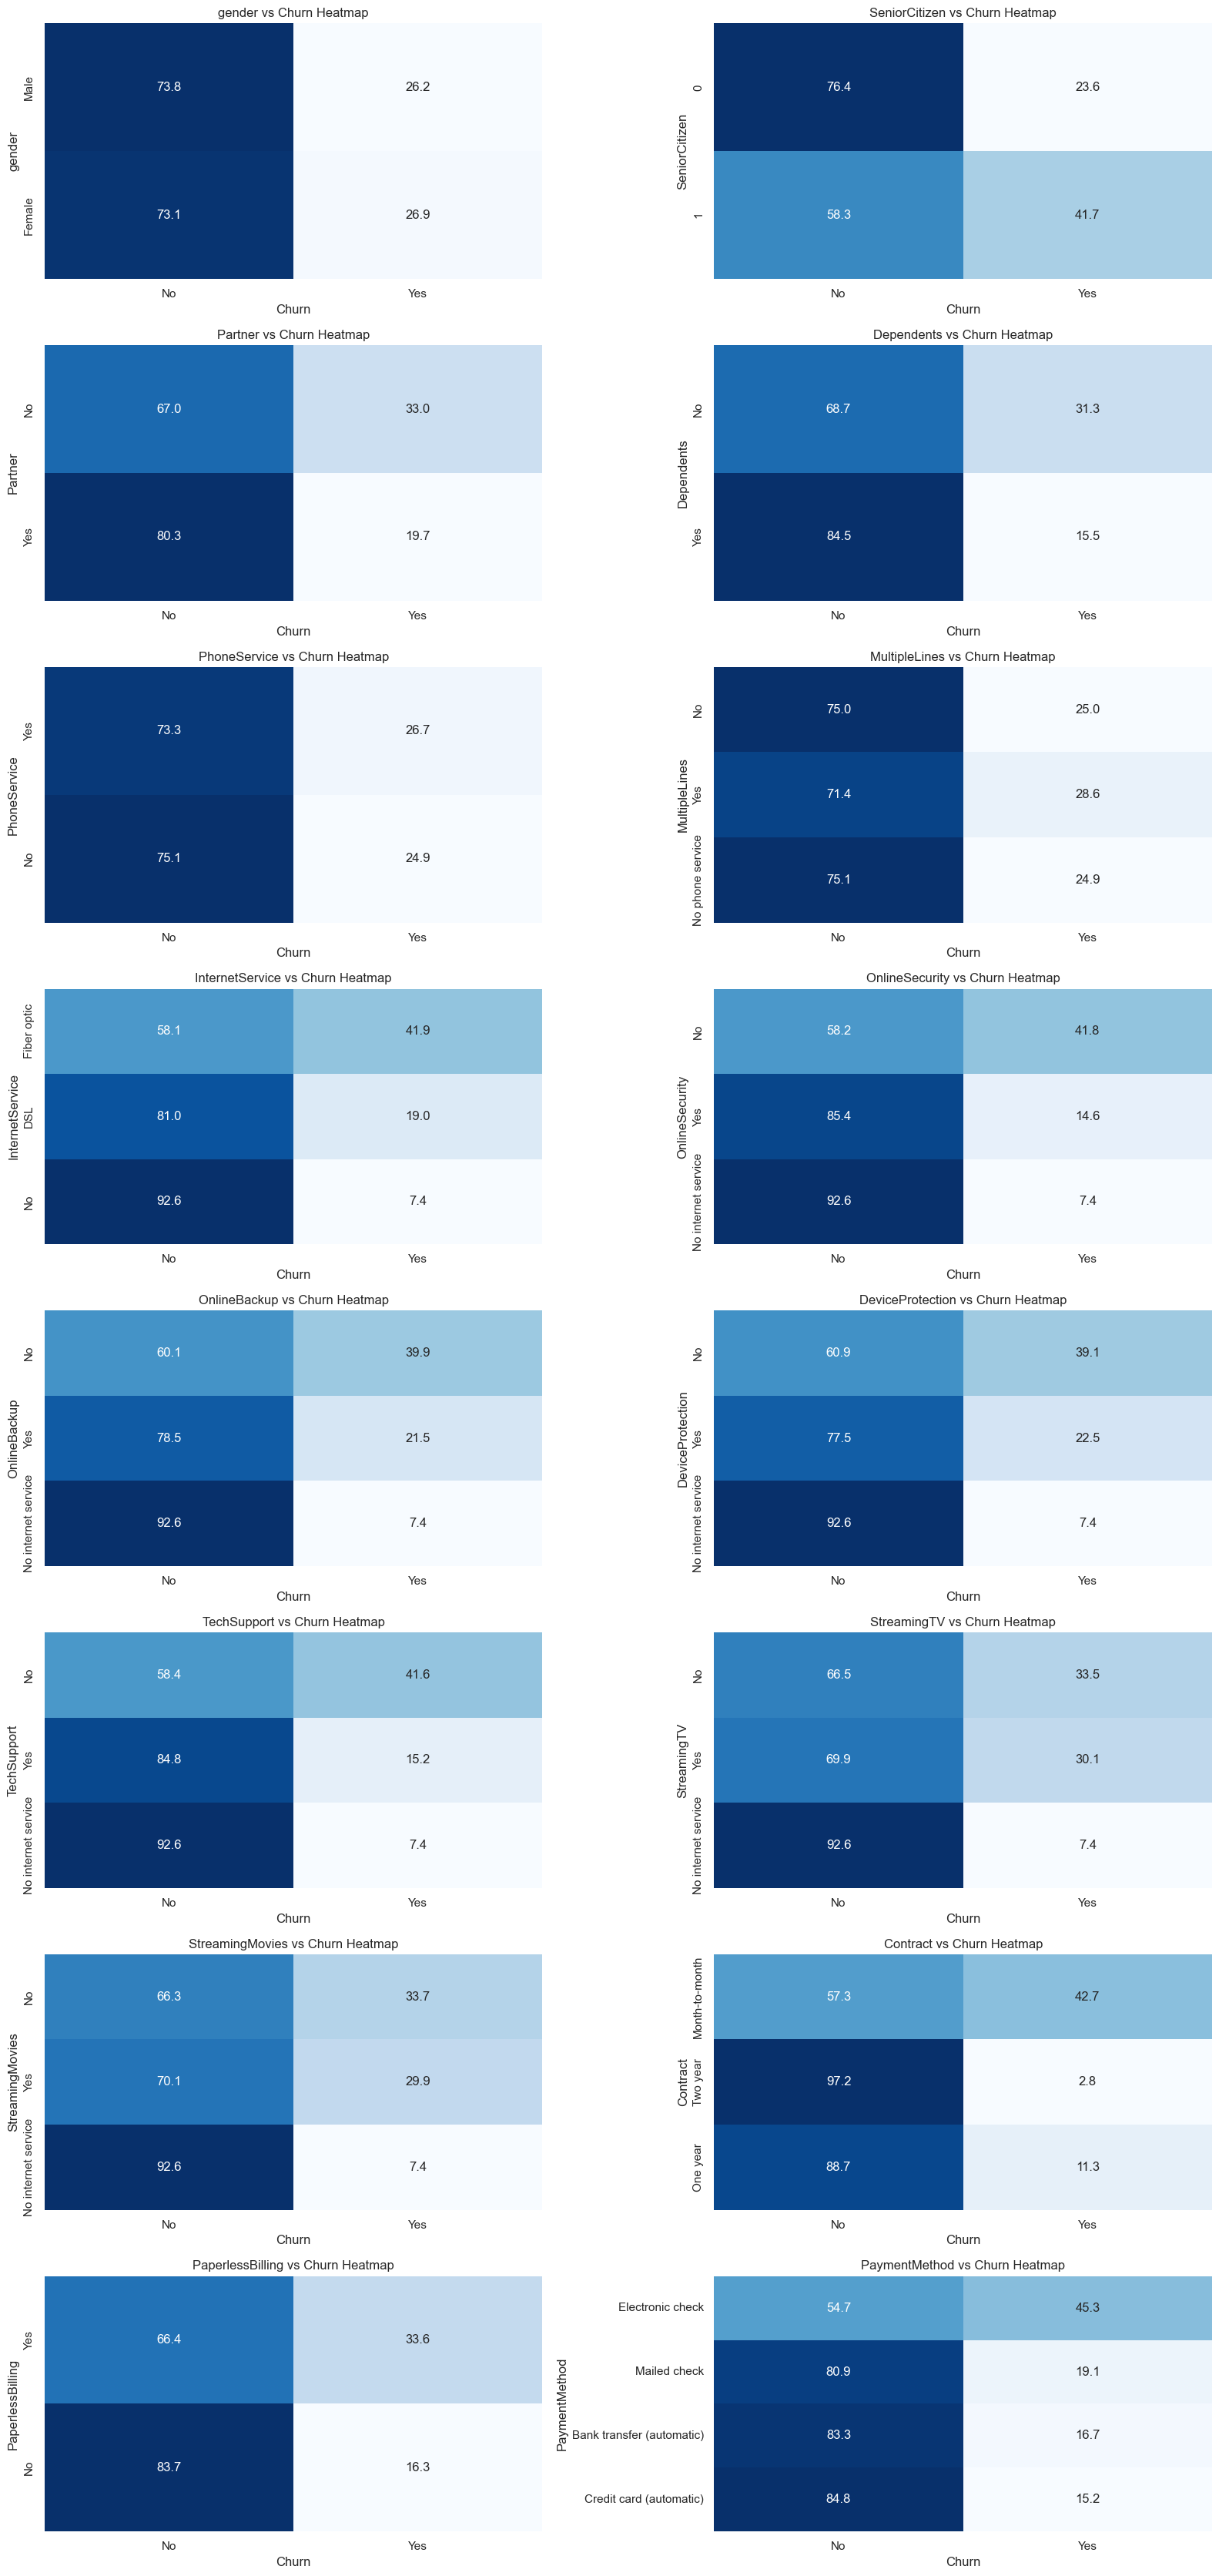

In [35]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    ax = axes[index]
    heatmap_table = pd.crosstab(
        df[column], df[target_column], normalize="index"
    ).mul(100)
    heatmap_table = heatmap_table.reindex(df[column].value_counts().index)
    sns.heatmap(
        heatmap_table,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{column} vs {target_column} Heatmap")
    ax.set_xlabel(target_column)
    ax.set_ylabel(column)

for index in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.savefig(
    CATEGORICAL_VS_TARGET_FIGURES_DIR / "categorical_vs_target_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


This heatmap shows the percentage of churned and non-churned customers within each category. The annotated values and color intensity make it easy to compare churn patterns across categories and quickly identify groups with relatively higher churn share.


### Categorical vs Target Insights

- Use the grouped count plots to compare how each churn class is distributed within every category, and use the churn-rate tables to see which category has the highest share of churn.
- Features where the `Yes` and `No` bars differ clearly across categories are stronger candidates for churn prediction, while features with very similar grouped bars are likely weaker signals.
- Pay special attention to multi-class features such as `Contract`, `InternetService`, and `PaymentMethod`, because they often show more visible churn differences than simple balanced categories.
- Structural labels such as `No internet service` and `No phone service` should be interpreted carefully: they are meaningful states, not ordinary missing values.
- The saved per-feature tables make it easier to report which categories are dominant, which have the highest churn rate, and which may need encoding attention later.
